# Day 17b (Extension): Autoencoder Intro — From Classifier to Image Reconstruction

> **Goal:** Learn how to convert an image classifier into an image-to-image model by changing only the head and loss function. Build a linear autoencoder (MNIST) and a convolutional autoencoder (CIFAR-10), and explore the latent space.

> **Prerequisite:** Day 17 (Build Your First CNN)

---

## Why This Extension Exists

You just built a CNN that classifies CIFAR-10 images into 10 categories. But **does the same CNN knowledge transfer to tasks that output images instead of labels?**

The answer is **yes** — the backbone architecture is identical. Only two things change:

| Component | Classifier (Day 17) | Autoencoder (Today) |
|---|---|---|
| **Head** | Flatten + Linear → class logits | Linear + Unflatten + ConvTranspose2d → reconstructed image |
| **Loss** | CrossEntropyLoss (compare labels) | MSELoss / L1Loss (compare pixels) |
| **Output** | 10 class probabilities | Same size as input (3×32×32) |

**Today's insight:** *Every image classification architecture can be turned into an image-to-image architecture. Just swap the head and loss.*

### Optics Connection

An autoencoder is like **compression then decompression** in a camera pipeline:
- **Encoder = compression**: Raw sensor data (12+ megapixels) → JPEG (compressed representation)
- **Bottleneck = JPEG file**: The compact representation that captures the essential information
- **Decoder = decompression**: JPEG → display image (hopefully close to the original)

The autoencoder learns to *compress* and *reconstruct* — without being told what's important, it discovers the structure of the data itself.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.decomposition import PCA

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## 1. Data Setup — MNIST for Linear Autoencoder

We start simple: 28×28 grayscale images (MNIST digits) with a **linear (MLP-based) autoencoder**. This revisits the architecture from Day 11 — no convolutions, just matrix multiplications.

**Why start with MNIST?**
- 28×28 = 784 pixels — small enough for a linear model
- Grayscale (1 channel) — easier to reconstruct than RGB
- We already know from Day 11 that MLPs can learn MNIST structure

MNIST — Train: 54000, Val: 6000, Test: 10000


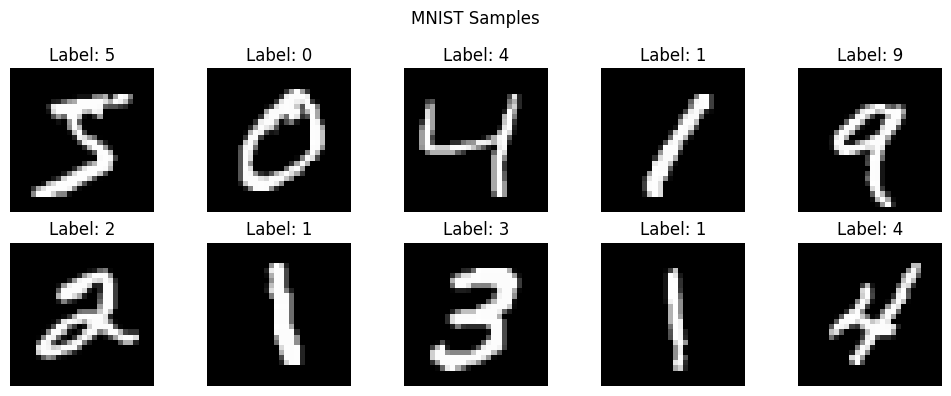

In [2]:
# MNIST data — no augmentation needed for autoencoder (we want clean reconstruction)
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
])

full_train_mnist = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform_mnist)
test_mnist = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform_mnist)

train_mnist, val_mnist = random_split(full_train_mnist, [54000, 6000],
                                        generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader_mnist = DataLoader(train_mnist, batch_size=BATCH_SIZE, shuffle=True)
val_loader_mnist   = DataLoader(val_mnist,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_mnist  = DataLoader(test_mnist,  batch_size=BATCH_SIZE, shuffle=False)

print(f"MNIST — Train: {len(train_mnist)}, Val: {len(val_mnist)}, Test: {len(test_mnist)}")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = full_train_mnist[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST Samples")
plt.tight_layout()
plt.show()

---
## 2. Linear Autoencoder (MLP-Based)

This is the simplest possible autoencoder: an MLP that maps 784 pixels → 128 latent dimensions → 784 pixels.

```
Input (784) → Linear(784, 256) → ReLU → Linear(256, 128) → ReLU → 
Linear(128, 256) → ReLU → Linear(256, 784) → Sigmoid → Output (784)
```

**Key concept:** The bottleneck (128 dimensions) forces the network to learn a **compressed representation**. If the bottleneck were 784 (same as input), the network could just copy pixels — but with compression, it must learn the *structure* of digits.

**From-scratch implementation:** We'll write the loss function conceptually first, then use the PyTorch built-in.

In [3]:
class LinearAutoencoder(nn.Module):
    """Simple MLP-based autoencoder for MNIST (28×28 = 784 pixels)."""

    def __init__(self, input_dim=784, bottleneck_dim=128):
        super().__init__()

        # Encoder: input → bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_dim),
            nn.ReLU(),
        )

        # Decoder: bottleneck → reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid(),  # Output between 0 and 1 (pixel values)
        )

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)  # (batch, 784)
        latent = self.encoder(x_flat)      # (batch, bottleneck_dim)
        reconstruction = self.decoder(latent)  # (batch, 784)
        # Reshape back to image format
        reconstruction = reconstruction.view(batch_size, 1, 28, 28)
        return reconstruction, latent


linear_ae = LinearAutoencoder(input_dim=784, bottleneck_dim=128).to(device)
total = sum(p.numel() for p in linear_ae.parameters())
print(linear_ae)
print(f"\nTotal parameters: {total:,}")

# Trace through
x = torch.randn(1, 1, 28, 28).to(device)
recon, latent = linear_ae(x)
print(f"\nInput:        {x.shape}")
print(f"Latent:       {latent.shape}")
print(f"Reconstruction: {recon.shape}")

LinearAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Total parameters: 468,368

Input:        torch.Size([1, 1, 28, 28])
Latent:       torch.Size([1, 128])
Reconstruction: torch.Size([1, 1, 28, 28])


### Understanding MSE Loss for Images

For classification, we used **CrossEntropyLoss** — which compares the predicted class probabilities to the true label.

For image reconstruction, we use **Mean Squared Error (MSE)** — which compares each pixel directly:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$$

Where $x_i$ is the original pixel value and $\hat{x}_i$ is the reconstructed pixel value.

**Why MSE makes intuitive sense for an optical engineer:**
- MSE is the pixel-level equivalent of **squared error in sensor measurements**
- Minimizing MSE = minimizing the average pixel error, like minimizing sensor noise
- PSNR (which we'll learn in Notebook 2) is directly derived from MSE: $\text{PSNR} = 10 \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)$

We'll also compare with **L1 Loss** (mean absolute error), which can produce sharper reconstructions.

In [4]:
# Training functions (same pattern as Day 17)
def train_one_epoch_ae(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    total = 0
    for images, _ in loader:  # Note: we don't need labels!
        images = images.to(device)
        reconstructions, _ = model(images)
        loss = loss_fn(reconstructions, images)  # Compare reconstruction to original
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total += images.size(0)
    return total_loss / total

@torch.no_grad()
def evaluate_ae(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    total = 0
    for images, _ in loader:
        images = images.to(device)
        reconstructions, _ = model(images)
        loss = loss_fn(reconstructions, images)
        total_loss += loss.item() * images.size(0)
        total += images.size(0)
    return total_loss / total

---
## 3. Train the Linear Autoencoder

**Note:** Autoencoders don't use labels — the input *is* the target. This is called **self-supervised learning**: the data provides its own supervision.

In [5]:
model_linear = LinearAutoencoder(input_dim=784, bottleneck_dim=128).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_linear.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_linear = {"train_loss": [], "val_loss": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Time':>5}")
print("-" * 40)

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch_ae(model_linear, train_loader_mnist, loss_fn, optimizer, device)
    val_loss = evaluate_ae(model_linear, val_loader_mnist, loss_fn, device)
    elapsed = time.time() - start

    history_linear["train_loss"].append(train_loss)
    history_linear["val_loss"].append(val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.6f} | {val_loss:8.6f} | {elapsed:4.1f}s")

print("\n✅ Training complete!")

Epoch | Train Loss | Val Loss |  Time
----------------------------------------
    1 |   0.044831 | 0.021932 |  2.6s
    5 |   0.008124 | 0.007741 |  2.0s
   10 |   0.005161 | 0.005171 |  2.0s
   15 |   0.003985 | 0.004018 |  2.1s
   20 |   0.003352 | 0.003453 |  2.0s

✅ Training complete!


### Visualize Reconstruction Results

Let's see how well the linear autoencoder reconstructs MNIST digits. The comparison shows original (top), reconstruction (middle), and pixel-wise error (bottom).

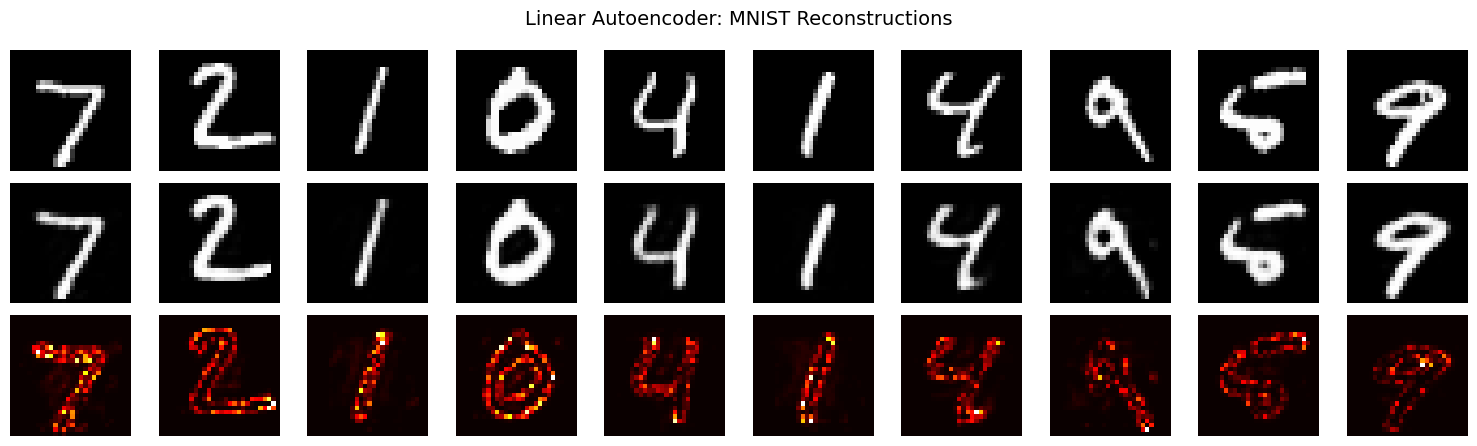

In [10]:
# Visualize reconstructions
model_linear.eval()
images, labels = next(iter(test_loader_mnist))
images = images.to(device)
with torch.no_grad():
    reconstructions, latents = model_linear(images)

fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for i in range(10):
    # Original
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_ylabel("Original", fontsize=10)

    # Reconstruction
    axes[1, i].imshow(reconstructions[i].cpu().detach().squeeze(), cmap="gray")
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_ylabel("Recon", fontsize=10)

    # Error (absolute difference)
    error = (images[i] - reconstructions[i]).abs().cpu().detach().squeeze()
    im = axes[2, i].imshow(error, cmap="hot")
    axes[2, i].axis("off")
    if i == 0: axes[2, i].set_ylabel("Error", fontsize=10)

plt.suptitle("Linear Autoencoder: MNIST Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

### Loss Curve

The training and validation loss curves should converge — this indicates the autoencoder is learning a generalizable compressed representation, not just memorizing the training images.

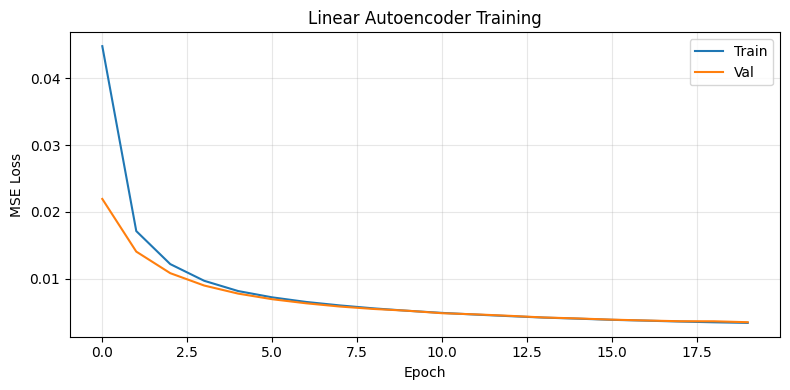

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history_linear["train_loss"], label="Train")
plt.plot(history_linear["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear Autoencoder Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Convolutional Autoencoder for CIFAR-10

Now we extend to CIFAR-10 (32×32 RGB images) using the **same CNN backbone from Day 17**, but with a twist:

1. **Encoder** = the feature extractor from Day 17 (Conv → BN → ReLU → Pool) — compresses spatial info
2. **Bottleneck** = a Linear layer that maps the flattened features to a compact latent vector
3. **Decoder** = reverses the encoder: Linear → Unflatten → ConvTranspose2d → ConvTranspose2d

### Why ConvTranspose2d?

`ConvTranspose2d` is the **learned upsampling** operation. While MaxPool2d reduces spatial dimensions, ConvTranspose2d increases them. Think of it as the reverse of convolution:

- **Conv2d:** kernel slides over input → smaller output (or same with padding)
- **ConvTranspose2d:** kernel expands each input position → larger output

**From-scratch intuition:** Imagine a 2×2 input being upsampled to 4×4. ConvTranspose2d places each input value and "spreads" it using the learned kernel weights.

In [12]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for CIFAR-10 (3×32×32).
    
    Architecture matches Day 17's SimpleCNN but replaces the classifier head
    with a decoder that reconstructs the image.
    """

    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder: same as Day 17's SimpleCNN.features
        self.encoder = nn.Sequential(
            # Block 1: 3 → 32, 32×32 → 16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 32 → 64, 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 64 → 128, 8×8 → 4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Bottleneck: compress 128*4*4 → latent_dim
        self.fc_enc = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * 4 * 4)

        # Decoder: mirror the encoder with ConvTranspose2d
        self.decoder = nn.Sequential(
            # Block 3 reverse: 128 → 64, 4×4 → 8×8
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Block 2 reverse: 64 → 32, 8×8 → 16×16
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Block 1 reverse: 32 → 3, 16×16 → 32×32
            nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
            nn.Sigmoid(),  # Pixel values to [0, 1]
        )

    def forward(self, x):
        # Encode
        encoded = self.encoder(x)  # (batch, 128, 4, 4)
        flattened = encoded.view(encoded.size(0), -1)  # (batch, 128*4*4)
        latent = self.fc_enc(flattened)  # (batch, latent_dim)

        # Decode
        expanded = self.fc_dec(latent)  # (batch, 128*4*4)
        reshaped = expanded.view(expanded.size(0), 128, 4, 4)  # (batch, 128, 4, 4)
        reconstruction = self.decoder(reshaped)  # (batch, 3, 32, 32)

        return reconstruction, latent


conv_ae = ConvAutoencoder(latent_dim=128).to(device)
total = sum(p.numel() for p in conv_ae.parameters())
print(conv_ae)
print(f"\nTotal parameters: {total:,}")

# Trace through
x = torch.randn(1, 3, 32, 32).to(device)
recon, latent = conv_ae(x)
print(f"Input:        {x.shape}")
print(f"Latent:       {latent.shape}")
print(f"Reconstruction: {recon.shape}")

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=2048, out_features=128, bias=True)
  (fc_dec): Linear(in_fe

### Verify: Trace Shapes Through the Conv Autoencoder

Following the same debugging habit from Day 17, let's verify each stage produces the expected dimensions.

In [13]:
# Detailed shape trace
x = torch.randn(1, 3, 32, 32).to(device)
print(f"Input:           {x.shape}")

with torch.no_grad():
    # Encoder blocks
    e = conv_ae.encoder[0](x)
    print(f"After Conv1:      {e.shape}")
    e = conv_ae.encoder[3](e)
    print(f"After Pool1:      {e.shape}")
    e = conv_ae.encoder[4](e)
    print(f"After Conv2:      {e.shape}")
    e = conv_ae.encoder[7](e)
    print(f"After Pool2:      {e.shape}")
    e = conv_ae.encoder[8](e)
    print(f"After Conv3:      {e.shape}")
    e = conv_ae.encoder[11](e)
    print(f"After Pool3:      {e.shape}")

    # Bottleneck
    flat = e.view(e.size(0), -1)
    print(f"After Flatten:    {flat.shape}")
    lat = conv_ae.fc_enc(flat)
    print(f"After FC Enc:     {lat.shape}  (latent space)")

    # Decoder
    d = conv_ae.fc_dec(lat)
    print(f"After FC Dec:     {d.shape}")
    d = d.view(d.size(0), 128, 4, 4)
    print(f"After Reshape:    {d.shape}")
    d = conv_ae.decoder[0](d)
    print(f"After ConvTrans1: {d.shape}")
    d = conv_ae.decoder[3](d)
    print(f"After ConvTrans2: {d.shape}")
    d = conv_ae.decoder[6](d)
    print(f"After ConvTrans3: {d.shape}  (reconstruction)")

Input:           torch.Size([1, 3, 32, 32])
After Conv1:      torch.Size([1, 32, 32, 32])
After Pool1:      torch.Size([1, 32, 16, 16])
After Conv2:      torch.Size([1, 64, 16, 16])
After Pool2:      torch.Size([1, 64, 8, 8])
After Conv3:      torch.Size([1, 128, 8, 8])
After Pool3:      torch.Size([1, 128, 4, 4])
After Flatten:    torch.Size([1, 2048])
After FC Enc:     torch.Size([1, 128])  (latent space)
After FC Dec:     torch.Size([1, 2048])
After Reshape:    torch.Size([1, 128, 4, 4])
After ConvTrans1: torch.Size([1, 64, 8, 8])
After ConvTrans2: torch.Size([1, 32, 16, 16])
After ConvTrans3: torch.Size([1, 3, 32, 32])  (reconstruction)


---
## 5. CIFAR-10 Data Setup

Same setup as Day 17: CIFAR-10 with train/val/test split. Note that we use **normalization** for autoencoder training — the model will predict normalized pixel values, so we denormalize for visualization.

In [14]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train_cifar = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_cifar = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_cifar, val_cifar = random_split(full_train_cifar, [45000, 5000],
                                       generator=torch.Generator().manual_seed(42))

train_loader_cifar = DataLoader(train_cifar, batch_size=128, shuffle=True)
val_loader_cifar   = DataLoader(val_cifar,   batch_size=128, shuffle=False)
test_loader_cifar  = DataLoader(test_cifar,  batch_size=128, shuffle=False)

classes = full_train_cifar.classes
print(f"CIFAR-10 — Train: {len(train_cifar)}, Val: {len(val_cifar)}, Test: {len(test_cifar)}")
print(f"Classes: {classes}")

CIFAR-10 — Train: 45000, Val: 5000, Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 6. Train the Convolutional Autoencoder

Training configuration:
- **Loss:** MSELoss (compare pixels)
- **Optimizer:** Adam, lr=1e-3
- **Epochs:** 20

This will take a few minutes. The reconstruction quality won't be perfect — CIFAR-10 has diverse objects (planes, cars, birds, dogs) — but you should see recognizable shapes and colors.

In [15]:
model_conv = ConvAutoencoder(latent_dim=128).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_conv.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_conv = {"train_loss": [], "val_loss": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Time':>5}")
print("-" * 40)

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch_ae(model_conv, train_loader_cifar, loss_fn, optimizer, device)
    val_loss = evaluate_ae(model_conv, val_loader_cifar, loss_fn, device)
    elapsed = time.time() - start

    history_conv["train_loss"].append(train_loss)
    history_conv["val_loss"].append(val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.6f} | {val_loss:8.6f} | {elapsed:4.1f}s")

print("\n✅ Training complete!")

Epoch | Train Loss | Val Loss |  Time
----------------------------------------
    1 |   0.728435 | 0.629778 |  6.0s
    5 |   0.575937 | 0.577404 |  4.6s
   10 |   0.565609 | 0.569313 |  4.7s
   15 |   0.563463 | 0.567188 |  4.7s
   20 |   0.562005 | 0.566316 |  4.7s

✅ Training complete!


### Visualize CIFAR-10 Reconstructions

Even though the model has a 128-dimensional bottleneck, it should capture the essential structure (object shape, approximate colors, position).

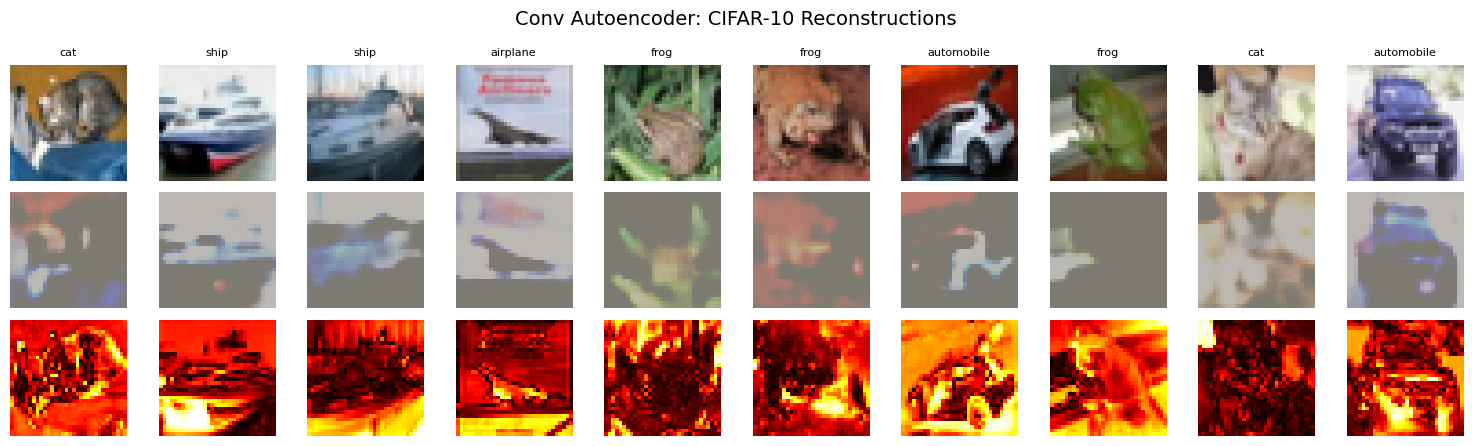

In [16]:
# Helper function to denormalize for visualization
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(1, 3, 1, 1)
    std = torch.tensor(std).view(1, 3, 1, 1)
    return tensor * std + mean

model_conv.eval()
images, labels = next(iter(test_loader_cifar))
images = images.to(device)
with torch.no_grad():
    reconstructions, latents = model_conv(images)

# Denormalize for visualization
images_dn = denormalize(images.cpu(), CIFAR_MEAN, CIFAR_STD).clamp(0, 1)
recons_dn = denormalize(reconstructions.cpu().detach(), CIFAR_MEAN, CIFAR_STD).clamp(0, 1)

fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for i in range(10):
    # Original
    axes[0, i].imshow(images_dn[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title(classes[labels[i]], fontsize=8)
    if i == 0: axes[0, i].set_ylabel("Original", fontsize=10)

    # Reconstruction
    axes[1, i].imshow(recons_dn[i].permute(1, 2, 0))
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_ylabel("Recon", fontsize=10)

    # Error
    error = (images_dn[i] - recons_dn[i]).abs().mean(dim=0)
    axes[2, i].imshow(error, cmap="hot")
    axes[2, i].axis("off")
    if i == 0: axes[2, i].set_ylabel("Error", fontsize=10)

plt.suptitle("Conv Autoencoder: CIFAR-10 Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

### Loss Curves

The loss should decrease steadily. The gap between train and val tells you about generalization.

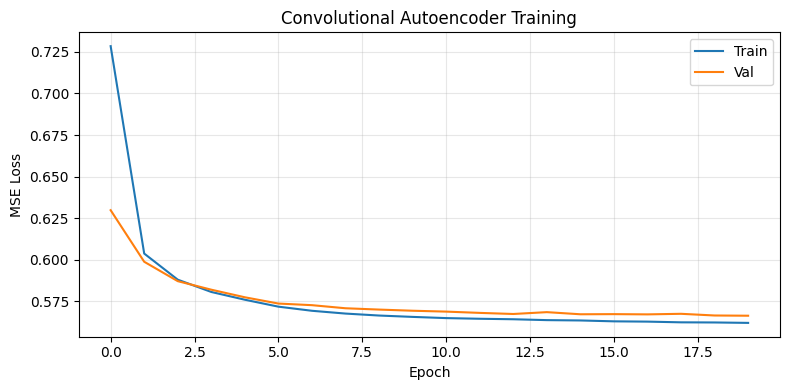

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history_conv["train_loss"], label="Train")
plt.plot(history_conv["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Convolutional Autoencoder Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Compare Upsampling Methods

ConvTranspose2d is powerful but can produce **checkerboard artifacts** — a grid-like pattern in the output. Let's compare it with `nn.Upsample + Conv2d`, which uses fixed interpolation (nearest/bilinear) followed by a regular convolution.

**The trade-off:**
- **ConvTranspose2d:** Learns the upsampling kernel — more flexible, but prone to artifacts
- **Upsample + Conv2d:** Fixed interpolation + learned refinement — fewer artifacts, but less expressive

In [18]:
class UpsampleDecoder(nn.Module):
    """Decoder that uses Upsample + Conv2d instead of ConvTranspose2d."""

    def __init__(self, in_channels=128, out_channels=3):
        super().__init__()
        self.decoder = nn.Sequential(
            # 4×4 → 8×8: upsample then conv
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 8×8 → 16×16
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 16×16 → 32×32
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(x)


# Compare output shapes
transpose_decoder = nn.Sequential(
    nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
    nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
    nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
)

upsample_decoder = UpsampleDecoder()

x = torch.randn(1, 128, 4, 4)
out_trans = transpose_decoder(x)
out_upsample = upsample_decoder(x)
print(f"ConvTranspose2d output: {out_trans.shape}")
print(f"Upsample+Conv2d output: {out_upsample.shape}")
print("\nBoth produce the same output size (1, 3, 32, 32) — good!")

ConvTranspose2d output: torch.Size([1, 3, 32, 32])
Upsample+Conv2d output: torch.Size([1, 3, 32, 32])

Both produce the same output size (1, 3, 32, 32) — good!


---
## 8. Explore the Latent Space

The bottleneck (latent space) is a compact 128-dimensional representation of the input image. Let's visualize it by reducing to 2D with PCA.

In [19]:
# Collect latent vectors and labels
all_latents = []
all_labels = []

model_conv.eval()
with torch.no_grad():
    for images, labels in test_loader_cifar:
        images = images.to(device)
        _, latents = model_conv(images)
        all_latents.append(latents.cpu())
        all_labels.append(labels)

all_latents = torch.cat(all_latents).numpy()
all_labels = torch.cat(all_labels).numpy()
print(f"Latent vectors: {all_latents.shape}")  # (10000, 128)

Latent vectors: (10000, 128)


Explained variance ratio: 0.214


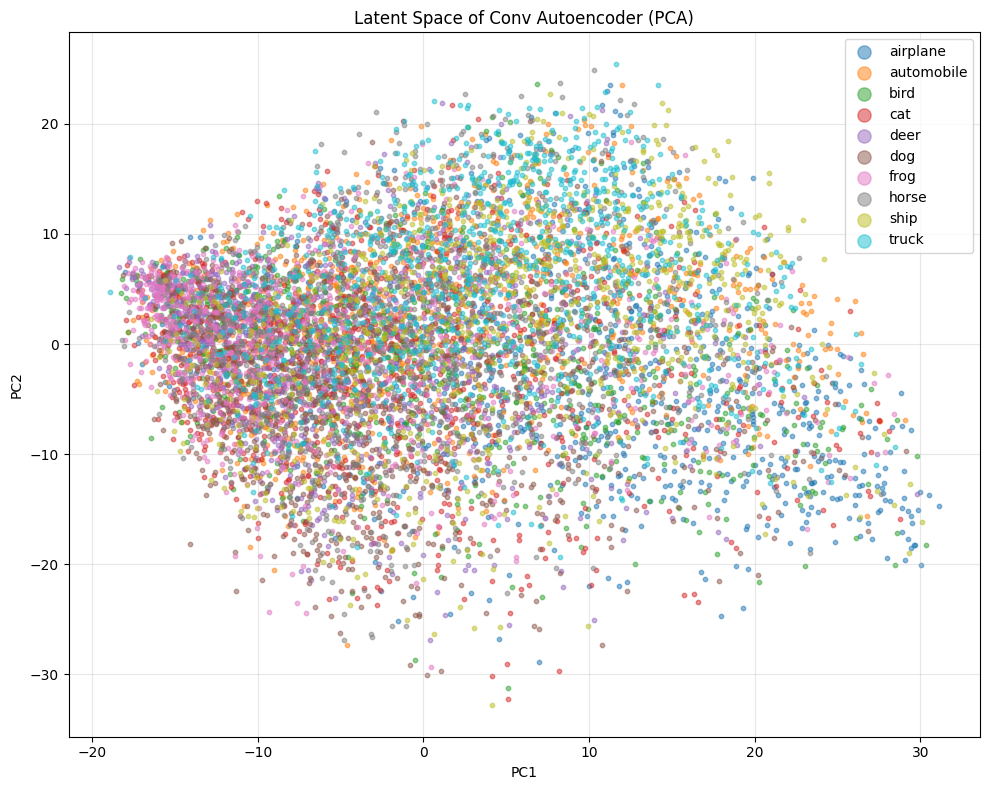

📝 Note: Even without being trained for classification, the latent space shows class clustering!
    The autoencoder organizes images by similarity in the latent space.


In [20]:
# PCA to 2D
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(all_latents)
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.arange(10))
for cls_idx in range(10):
    mask = all_labels == cls_idx
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=[colors[cls_idx]], label=classes[cls_idx],
                alpha=0.5, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Space of Conv Autoencoder (PCA)")
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("📝 Note: Even without being trained for classification, the latent space shows class clustering!")
print("    The autoencoder organizes images by similarity in the latent space.")

---
## 🧪 Exercises

### Exercise 1: Bottleneck Size
Change the bottleneck dimension from 128 to 64, 32, 16, 8, 4. At what point does reconstruction quality noticeably drop?

### Exercise 2: Upsample+Conv2d vs ConvTranspose2d
Re-train the convolutional autoencoder using `UpsampleDecoder` instead of ConvTranspose2d. Compare reconstruction quality and training time.

### Exercise 3: Denoising Autoencoder (Preview)
Add Gaussian noise (σ=0.1) to the input images during training, but keep the target as clean images. Train the same ConvAutoencoder. Does it learn to denoise? (This is a preview of Notebook 2!)

### Exercise 4: L1 Loss vs MSE
Replace MSELoss with L1Loss (mean absolute error). Which produces sharper reconstructions?

In [ ]:
# Exercise 1: Your code here — try different bottleneck sizes

In [ ]:
# Exercise 2: Your code here — use UpsampleDecoder

In [ ]:
# Exercise 3: Your code here — add noise to input, keep clean target

In [ ]:
# Exercise 4: Your code here — try L1Loss

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **Autoencoder** | Encoder → bottleneck → decoder; learns to compress and reconstruct |
| **From classifier to AE** | Same CNN backbone, different head (decoder), different loss (MSE) |
| **ConvTranspose2d** | Learned upsampling — reverses the effect of MaxPool2d |
| **MSE loss** | Pixel-by-pixel comparison — intuitive for optics/imaging |
| **Latent space** | The bottleneck learns a compressed representation that organizes data by similarity |
| **Self-supervised** | Input = target — the data provides its own supervision |

**Next up (Notebook 2):** We'll apply these concepts to real image restoration tasks — denoising, deblurring, and super-resolution — using U-Net with skip connections!